Import library

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [30]:
# Inisisalisasi visulaisasi
%matplotlib inline

Langkah 1 : Persiapan dataset

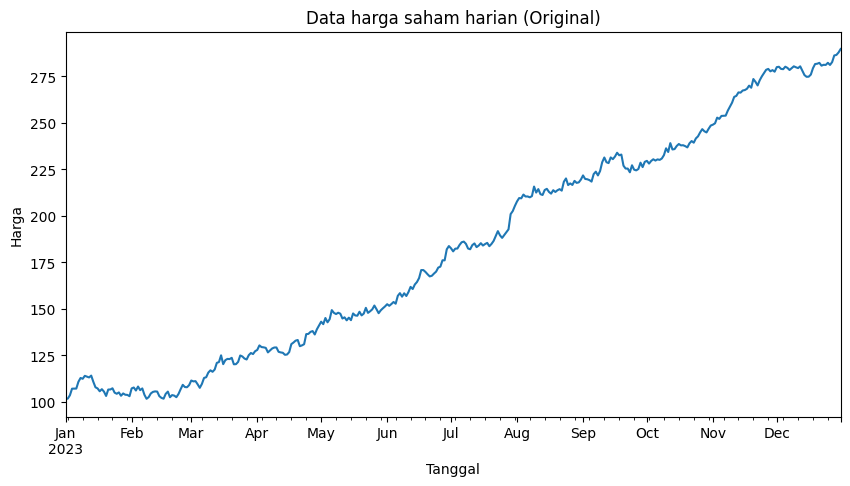

In [31]:
# 1. Membuat data deret waktu  sintetis (Tren Naik)
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', end="2023-12-31", freq="D")
n_days = len(date_rng)

# Harga = Base + Trend + Noise
harga = 100 + np.cumsum(np.random.normal(0.5, 2, n_days))
df = pd.DataFrame({"Tanggal" : date_rng, "Harga": harga})

# sangat penting: Menjadikan tanggal sebagai index
df.set_index('Tanggal', inplace=True)

# Visualisasi Data Mentah
df['Harga'].plot(figsize=(10, 5), title = "Data harga saham harian (Original)")
plt.ylabel("Harga")
plt.show()

Langkah 2 : uji stasioneritas (ADF Test)

In [32]:
def check_stationarity(timeseries):
  print("Hasil Uji Augmented Dickey-Fuller")
  result = adfuller(timeseries)
  print(f"ADF Statistic: {result[0]}")
  print(f'p-value: {result[1]}' )
  print("Critical Values:")
  for key , value in result[4].items():
    print(f'{key}:{value}')

  if result[1] <= 0.05:
    print("\nKesimpulan: Data STATIONER (Tolak H0)")
  else:
    print("\nKesimpulan: Data TIDAK STATIONER (Gagal Tolak H0)")

check_stationarity(df['Harga'])


Hasil Uji Augmented Dickey-Fuller
ADF Statistic: 0.9152354350421525
p-value: 0.9932859663324898
Critical Values:
1%:-3.448493650810824
5%:-2.8695352280356556
10%:-2.5710293341377715

Kesimpulan: Data TIDAK STATIONER (Gagal Tolak H0)


Langkah 3 : Transformasi Data (differencing)

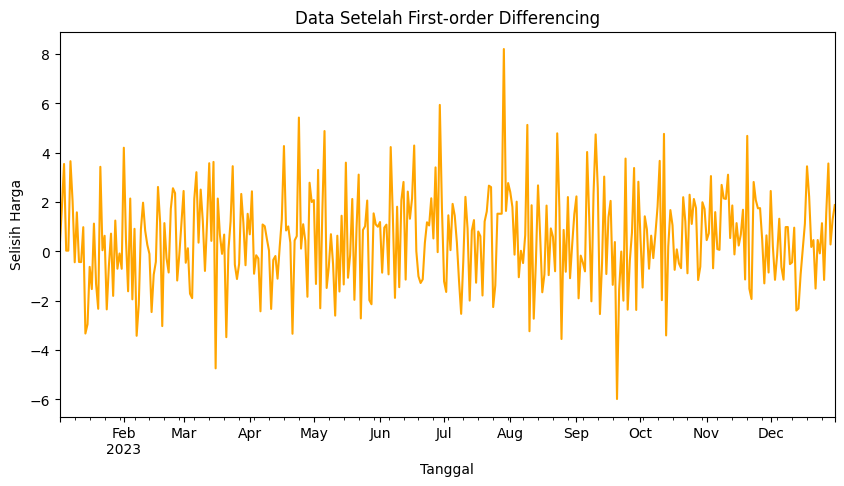

Hasil Uji Augmented Dickey-Fuller
ADF Statistic: -20.198792513037233
p-value: 0.0
Critical Values:
1%:-3.448493650810824
5%:-2.8695352280356556
10%:-2.5710293341377715

Kesimpulan: Data STATIONER (Tolak H0)


In [33]:
# Menghitung selisih (y_t - y_t-1)
df_diff = df['Harga'].diff().dropna()
# Visualisasi Data Setelah Differencing
df_diff.plot(figsize=(10, 5), title='Data Setelah First-order Differencing', color='orange')
plt.ylabel('Selisih Harga')
plt.show()
# Uji ulang stasioneritas pada data hasil transformasi
check_stationarity(df_diff)

Langkah 4: Analisis Korelasi (ACF & PACF)

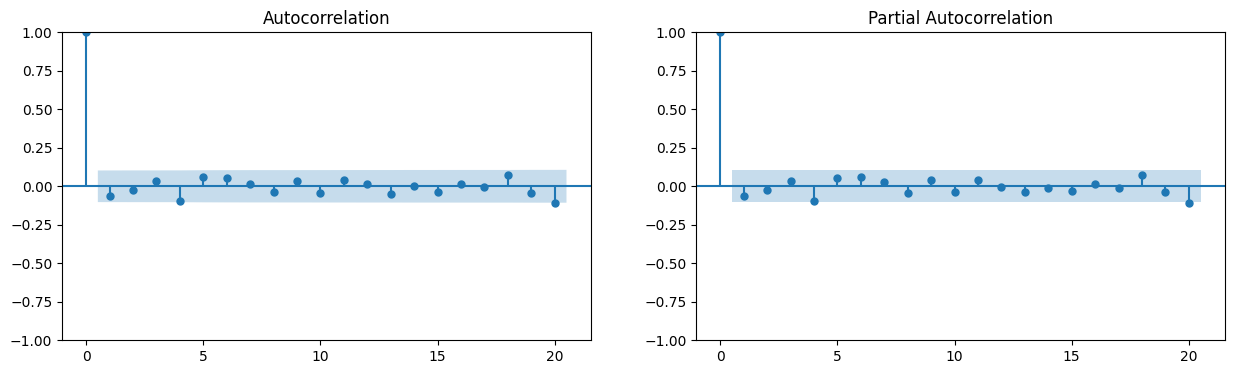

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df_diff, lags=20, ax=axes[0])
plot_pacf(df_diff, lags=20, ax=axes[1])
plt.show()


Langkah 5: Feature Engineering (Lagging)

In [35]:
# Membuat fitur dari nilai kemarin (X) untuk menebak hari ini (y)
df['Harga_Kemarin (Lag-1)'] = df['Harga'].shift(1)
# Menghapus baris pertama yang bernilai NaN akibat proses shift
df_supervised = df.dropna()

print("\nData dalam format Supervised Learning (Siap untuk ML):")
print(df_supervised.head())


Data dalam format Supervised Learning (Siap untuk ML):
                 Harga  Harga_Kemarin (Lag-1)
Tanggal                                      
2023-01-02  101.716900             101.493428
2023-01-03  103.512277             101.716900
2023-01-04  107.058336             103.512277
2023-01-05  107.090030             107.058336
2023-01-06  107.121756             107.090030
